In [1]:
!pip install hstrat downstream iplotx teeplot phyloframe

In [2]:
import seaborn as sns
import pandas as pd
import typing
import tqdm
import teeplot.teeplot as tp
import phyloframe.legacy as pfl
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path


In [3]:
!wget https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/track_ca.py
!wget https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/tree/_draw_scatter_tree.py

--2026-05-12 03:01:13--  https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/track_ca.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18325 (18K) [text/plain]
Saving to: ‘track_ca.py.1’

track_ca.py.1       100%[===================>]  17.90K  --.-KB/s    in 0.001s  

2026-05-12 03:01:13 (24.1 MB/s) - ‘track_ca.py.1’ saved [18325/18325]

--2026-05-12 03:01:13--  https://raw.githubusercontent.com/mmore500/hstrat-synthesis/refs/heads/main/pylib/tree/_draw_scatter_tree.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response.

In [4]:
!curl -L https://osf.io/download/5g3rz/ -o phylos.pkl

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 67.4M  100 67.4M    0     0  23.5M      0  0:00:02  0:00:02 --:--:-- 43.7M


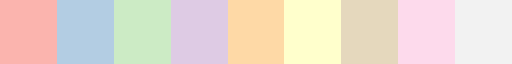

In [5]:
cmap = plt.get_cmap("Pastel1")
cmap

In [6]:
def add_position_label(df: pd.DataFrame, vertices: list[tuple[int, int]], label_as: str) -> None:
    if "position" not in df.columns:
        df["position"] = np.select([df["extant"].astype(bool)], ["unsampled"], default="inner node")
    in_shape = matplotlib.path.Path(vertices).contains_points(
        np.vstack([df["row"].to_numpy(), df["col"].to_numpy()]).T
    ) & df["extant"]
    df["position"] = np.select([in_shape], [label_as], default=df["position"])

In [7]:
BORDER_SAMPLES = [
    [(550, 0), (2300, 500), (2225, 725), (500, 175)],
    [(0, 0), (0, 2300), (2300, 2300), (2300, 0)],
]
MIDDLE_SAMPLES = [
    [(800, 650), (1550, 900), (1330, 1550), (580, 1300)],
    [(700, 250), (290, 1480), (1600, 1850), (1950, 650)],
    [(700, 275), (1900, 625), (1810, 850), (610, 500)],
    [(1600, 525), (1900, 625), (1475, 1800), (1175, 1700)],
]

In [8]:
import pickle
with open("phylos.pkl", "rb") as f:
    phylos = pickle.load(f)
for p in phylos:
    if "position" in p.columns:
        del p["position"]
    p.loc[0, "origin_time"] = 0
    add_position_label(p, BORDER_SAMPLES[0], "sampled border")
    add_position_label(p, MIDDLE_SAMPLES[3], "sampled middle")

In [9]:
df = phylos[0]
df[["position"]].value_counts()

position      
unsampled         37790
sampled border     9498
sampled middle     6684
inner node          826
Name: count, dtype: int64

In [10]:
def plot_outlier_regions(input_df: pd.DataFrame, ax=None):
    df = input_df.copy()
    ax = sns.scatterplot(data=phylos[0][phylos[0]["extant"] == True], x="col", y="row", s=0.5, linewidth=0, palette={
            "sampled border": cmap.colors[0],
            "sampled middle": cmap.colors[1],
            "unsampled": cmap.colors[-3]
    }, hue="position", ax=ax)
    ax.set_aspect("equal")
    ax.legend(title="position", markerscale=5)

In [11]:
import _draw_scatter_tree
from importlib import reload
_draw_scatter_tree = reload(_draw_scatter_tree)

def plot(df: pd.DataFrame, color_by: typing.Optional[str] = None, scatter_kws: dict = {}, tree_kws: dict = {}, **kwargs):
    return _draw_scatter_tree.draw_scatter_tree(
        df,
        hue=color_by,
        scatter_kws=dict(
            alpha=0.8,
            edgecolor="none",
            legend=True,
        ) | scatter_kws,
        scatter_shuffle=1,
        tree_kws=dict(
            edge=dict(
                color="gainsboro",
                linewidth=0.5,
            ),
            margins=-0.05,
            layout_angular=True,
        ) | tree_kws,
        **kwargs,
    )

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(


In [12]:
COLLESS_CUTOFF_TIME = 13504
DELTA_CUTOFF_TIME = 12000

In [13]:
def plot_colless_index_trees(input_df: pd.DataFrame, key: str, input_ax=None):
    df = phylos[1].copy()
    df["extant"] = df["position"] == key
    df = pfl.alifestd_prune_extinct_lineages_asexual(df)
    df = df[df["origin_time"] < COLLESS_CUTOFF_TIME]
    df[key] = df["extant"]
    color = cmap.colors[0] if key == "sampled border" else cmap.colors[1]
    ax = plot(
        df,
        color_by=key,
        tree_kws={"edge": {"color": [color]}},
        scatter_kws={"palette": [color]},
        ax=input_ax,
    )
    ax.get_legend().remove()

In [14]:
def sample_colless_index_data(input_df: pd.DataFrame, n_samples: int):
    tree_generators = (pfl.alifestd_make_edge_split, pfl.alifestd_make_leaf_split)

    data = {
        key: {
            "source": [],
            "colless_index": []
        }
        for key in ("sampled border", "sampled middle")
    }
    observed = {}

    for key in "sampled border", "sampled middle":
        df = input_df.copy()
        df["extant"] = (df["position"] == key)
        df = pfl.alifestd_prune_extinct_lineages_asexual(df)
        df = pfl.alifestd_collapse_unifurcations(df)
        df = df[df["origin_time"] < COLLESS_CUTOFF_TIME]
        df = pfl.alifestd_mark_colless_like_index_mdm_asexual(df)
        observed[key] = df["colless_like_index_mdm"][0]
        leaf_node_count = pfl.alifestd_count_leaf_nodes(df)
        for _ in tqdm.trange(n_samples, desc=f"sampling trees for {key=}"):
            for f in tree_generators:
                tree = f(leaf_node_count)
                tree = pfl.alifestd_mark_colless_like_index_mdm_asexual(tree)
                data[key]["source"].append(f.__name__.removeprefix("alifestd_make_"))
                data[key]["colless_index"].append(tree["colless_like_index_mdm"][0])

    return data, observed

In [15]:
def plot_colless_index_data(sampled: dict, observed: dict, key: str, input_ax=None):
    COLOR = "#464c5e"
    OBSERVED_COL_NAME = "observed"
    tree_generators = (pfl.alifestd_make_edge_split, pfl.alifestd_make_leaf_split)

    df = pd.DataFrame(sampled[key])
    lower_bound = df["colless_index"].max()
    upper_bound = df["colless_index"].min()
    for f in tree_generators:
        real_name = f.__name__.removeprefix("alifestd_make_")
        lower_bound = min(lower_bound, df[df["source"] == real_name]["colless_index"].quantile(0.025))
        upper_bound = max(upper_bound, df[df["source"] == real_name]["colless_index"].quantile(0.975))
    color = cmap.colors[0] if key == "sampled border" else cmap.colors[1]
    ax = sns.boxplot(
        data=df,
        x="source",
        y="colless_index",
        showfliers=False,
        width=0.2,
        order=("leaf_split", "edge_split", OBSERVED_COL_NAME),
        boxprops={"facecolor": COLOR, "edgecolor": COLOR},
        whiskerprops={"color": COLOR},
        medianprops={"color": COLOR},
        capprops={"linewidth": 0},
        ax=input_ax,
    )
    ax = sns.scatterplot(
        data=pd.DataFrame({
            "colless_index": [observed[key]],
            "source": [OBSERVED_COL_NAME],
        }),
        x="source",
        y="colless_index",
        color=color,
        ax=ax,
    )
    y_max = ax.get_ylim()[1]
    ax.set_ylim([0, y_max * 1.25])
    ax.axhspan(lower_bound,  upper_bound, color=f"{COLOR}20")
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    return ax

In [16]:
def plot_origin_time_delta(input_df: pd.DataFrame, input_ax=None):
    dfs = [
        input_df.assign(extant=input_df["position"] == key)
          .pipe(pfl.alifestd_prune_extinct_lineages_asexual)
        for key in ("sampled border", "sampled middle")
    ]

    cutout_dfs = [
        df[(df["origin_time"] < COLLESS_CUTOFF_TIME)]
          .pipe(pfl.alifestd_collapse_unifurcations)
          .pipe(pfl.alifestd_mark_origin_time_delta_asexual)
        for df in dfs
    ]

    df = pd.concat(cutout_dfs, keys=["border", "middle"]).reset_index(level=0).rename(columns={'level_0': 'source'})
    original_df = df.copy()
    for src in ("border", "middle"):
        original_df[f"{src}_marker_type"] = "."
        original_df[f"{src}_hue"] = "#ffffff"
    markers = 'osDv'

    is_first_result = True

    for i, src in enumerate(("border", "middle")):
        for j, m in enumerate(markers):
            plot_df = df[(df["source"] == src) & (df["origin_time"] < DELTA_CUTOFF_TIME)].copy()
            plot_df["marker_col"] = range(len(plot_df))
            plot_df.loc[plot_df["marker_col"] % len(markers) != j, "origin_time"] = 1e10
            colors = sns.dark_palette(cmap.colors[i], n_colors=len(plot_df["origin_time"].unique()))[1:] + [(0, 0, 0, 0)]
            for id in plot_df[plot_df["marker_col"] % len(markers) == j]["id"]:
                original_df.loc[original_df["id"] == id, f"{src}_marker_type"] = m
                color_to_be_plotted = colors[sorted(plot_df["origin_time"].unique()).index(original_df.loc[original_df["id"] == id, "origin_time"].values[0])]
                original_df.loc[original_df["id"] == id, f"{src}_hue"] = matplotlib.colors.rgb2hex(color_to_be_plotted)
            ax = sns.swarmplot(
                data=plot_df,
                y="origin_time_delta",
                x="source",
                hue="origin_time",
                palette=colors,
                order=("border", "middle"),
                legend=False,
                marker=m,
                ax=input_ax,
            )


    ax.tick_params(axis='y', which='both', labelleft=False, left=False, labelright=True, right=True)
    ax.yaxis.set_label_position('right')
    return original_df, ax

In [17]:
def plot_origin_time_delta_trees(input_df: pd.DataFrame, marker_info_df: pd.DataFrame, key: str, input_ax=None):
    df = input_df.copy()
    df["extant"] = df["position"] == key
    df = pfl.alifestd_prune_extinct_lineages_asexual(df)
    df = df[df["origin_time"] < COLLESS_CUTOFF_TIME]
    df = pfl.alifestd_collapse_unifurcations(df)

    src = key[-6:]
    color = cmap.colors[0] if src == "border" else cmap.colors[1]
    markers = list(marker_info_df[marker_info_df["source"] == src][f"{src}_marker_type"])
    palette = list(marker_info_df[marker_info_df["source"] == src][f"{src}_hue"])

    return plot(
        df,
        "id",
        tree_kws={"edge": {
            "color": [color],
            "linewidth": 0.01,
        }},
        scatter_kws={
            "markers": markers,
            "palette": palette,
            "legend": False
        },
        collapse_unifurcations=False,
        style="id",
        ax=input_ax,
    )

### (a) A visualization of the outlier CA displaying sampled regions for "border" (red) and "middle" (blue) cells

teeplots/viz=plot-outlier-regions+ext=.pdf
teeplots/viz=plot-outlier-regions+ext=.png


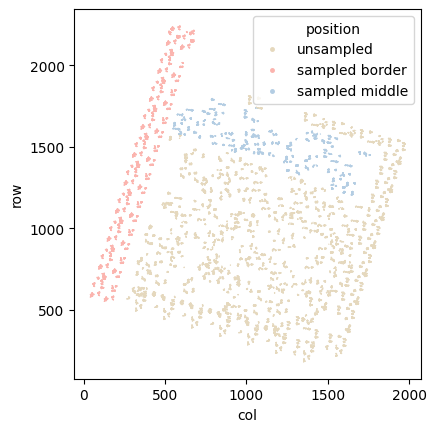

In [18]:
with tp.teed(
    plot_outlier_regions,
    phylos[1],
) as ax:
    ...

(b) An analysis on the significance of the imbalance we see in each trimmed tree (left), using edge split and leaf split sampling to randomly generate trees of the same size and determining the range of imbalance values (right).

sampling trees for key='sampled middle': 100%|██████████| 10000/10000 [01:01<00:00, 163.30it/s]


teeplots/viz=plot_colless_data+ext=.pdf
teeplots/viz=plot_colless_data+ext=.png


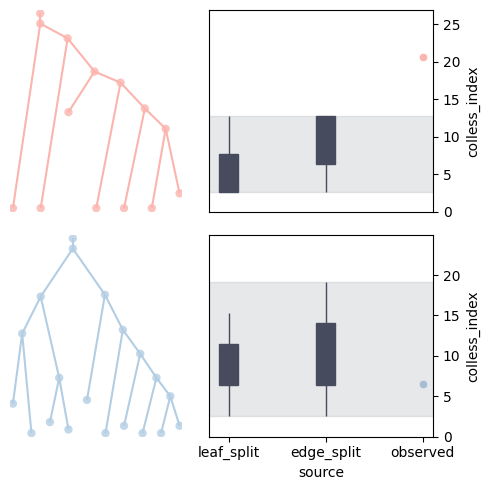

In [19]:
with tp.teed(
  plt.subplots,
  2,
  2,
  tight_layout=True,
  figsize=(5, 5),
  gridspec_kw={'width_ratios': [1, 1.3]},
  teeplot_outattrs={
      "viz": "plot_colless_data",
}) as (fig, axes):
    plot_colless_index_trees(phylos[1], "sampled border", axes[0][0])
    plot_colless_index_trees(phylos[1], "sampled middle", axes[1][0])
    sampled, observed = sample_colless_index_data(phylos[1], 10000)
    plot_colless_index_data(sampled, observed, "sampled border", axes[0][1])
    axes[0][1].set_xlabel(None)
    axes[0][1].set_xticks([])
    plot_colless_index_data(sampled, observed, "sampled middle", axes[1][1])


(c) Branch lengths of inner edges in sampled trees (left), displayed as a swarmplot (right) with markers corresponding to nodes in each tree.

teeplots/viz=plot_branch_length_data+ext=.pdf
teeplots/viz=plot_branch_length_data+ext=.png


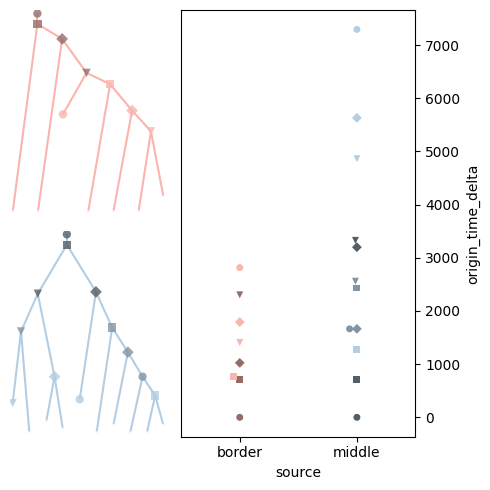

In [20]:
with tp.teed(
  plt.subplot_mosaic,
  [["border", "wait_times"], ["middle", "wait_times"]],
  tight_layout=True,
  figsize=(5, 5),
  gridspec_kw={'width_ratios': [1, 1.5]},
  teeplot_outattrs={
      "viz": "plot_branch_length_data",
}) as (fig, axes):
    original_df, _ = plot_origin_time_delta(phylos[1], axes["wait_times"])
    plot_origin_time_delta_trees(phylos[1], original_df, "sampled border", axes["border"])
    plot_origin_time_delta_trees(phylos[1], original_df, "sampled middle", axes["middle"])